# Computer Vision Note Book.

### 0. Computer vision libraries

* torchvision
* torchvision.datasets
* torchvision.models
* torchvision.transforms
* torch.untils.data.dataset
* torch.untils.data.Dataloader

In [291]:
# import pytorch
import torch
from torch import nn

# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib.pyplot as plt for visualization
import matplotlib.pyplot as plt

# check version
print(torch.__version__)

2.10.0+cu128


### 1. Getting a dataset

In [292]:
# setup a training dataset
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)


In [293]:
len(train_data), len(test_data)

(60000, 10000)

In [294]:
# see the first training examples
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [295]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [296]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [297]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [298]:
# check the shape of our image
print(f"Image shape: {image.shape}")
print(f"image Label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28])
image Label: Ankle boot


### 1.2 Visualize our data

Image shape: torch.Size([1, 28, 28])


(Text(0.5, 1.0, '9'),)

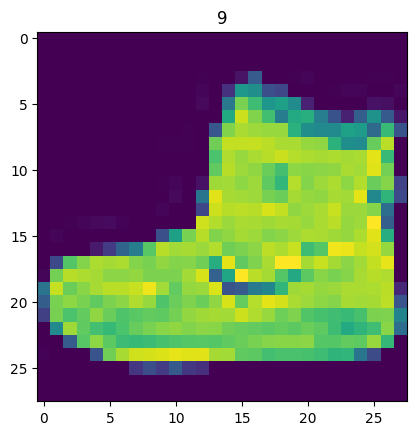

In [299]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label),

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

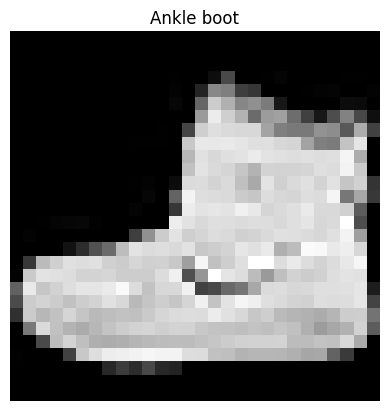

In [300]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]),
plt.axis(False)

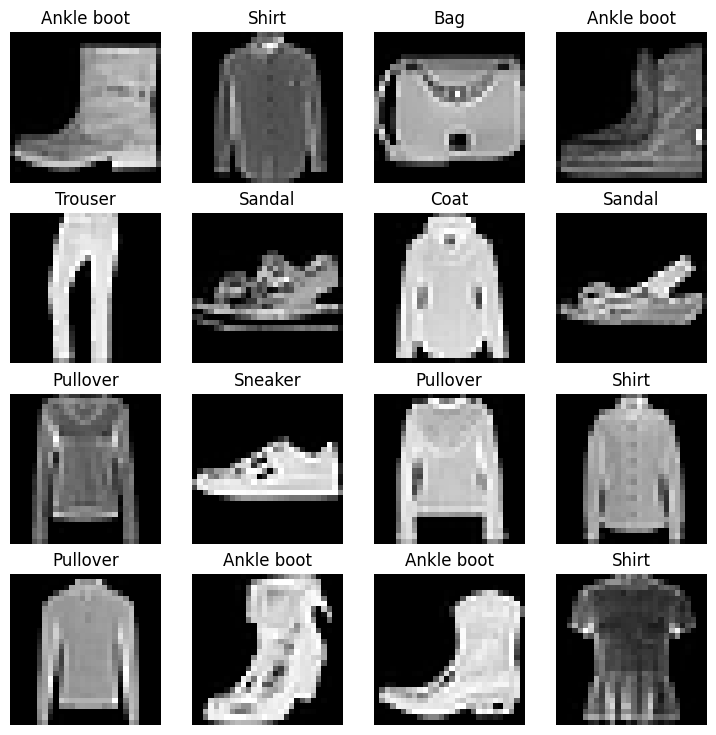

In [301]:
# plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis("off"),


do you think these item of clothing could be modelled with pure linear lines? or do you think we will need non=linearities?

In [302]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

### 2. prepare DataLoader

In [303]:
#
from torch.utils.data import DataLoader
BATCH_SIZE = 32
# setup the batch size hyperparameter
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c168230b440>,
 <torch.utils.data.dataloader.DataLoader at 0x7c16823375c0>)

In [304]:
# Let's check out what we have created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}....")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7c168230b440>, <torch.utils.data.dataloader.DataLoader object at 0x7c16823375c0>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batches of 32....


In [305]:
#
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


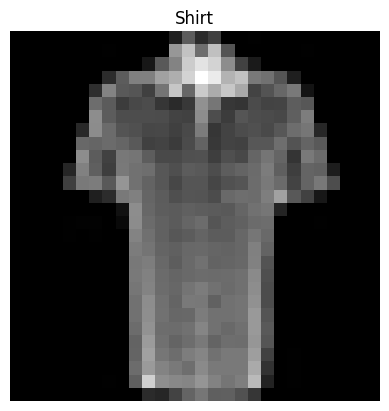

In [306]:
# show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

### 3. Model 0: Build a basline model

In [307]:
# creating a flatten model or layer
flatten_model = nn.Flatten()

# get a single sample - USE AN IMAGE, not a label!
x = train_features_batch[0]  # ← Changed from train_labels_batch

# flatten the sample
output = flatten_model(x)

# print out what happens
print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [308]:

class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):

        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [309]:
torch.manual_seed(42)

# setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape=28*28, # this is 28*28
    hidden_units=10,
    output_shape=len(class_names)

).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [310]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [311]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics.

* nn.Crossentropy
* optimizer

In [312]:
import requests
from pathlib import Path

# download helper functions from learn python repo
if Path("helper_functions.py").is_file():
  print(f"helper_functions.py already exists, skipping download...")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)



helper_functions.py already exists, skipping download...


In [313]:
#Import accuracy metric
from helper_functions import accuracy_fn

# setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

### 3.2 Creating a function to time our experiments

1. model performance
2. how fast it runs

In [314]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device=None):

  """ prints difference between start and end time """

  total_time = end - start

  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


In [315]:
start_time = timer()
# some code...
end_time = timer()
print_train_time(start=start_time, end=end_time, device="cpu")


Train time on cpu: 0.000 seconds


3.4452999898348935e-05

### 3.3 Creating  a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss per batch.
3.Loop through testing batches, perform testing steps, calculate the test loss per batch.
3. print out what's happening.
4. Time it all(for fun)


In [316]:
# import tgdm for progress bar
from tqdm.auto import tqdm

# set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# set the number of epochs
epochs = 3

# creating training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---")
  ### Training
  train_loss = 0
  # add a loss to to loop through the training batches
  for batch, (x, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(x)

    # 2. calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss

    # 3. optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()
    # 5. optimizer step
    optimizer.step()

    # print out what happen

    if batch % 400 == 0:
      print(f"Looked at: {batch*len(x)}/{len(train_dataloader.dataset)} samples")



  # divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for x_test, y_test in test_dataloader:
      # 1. forward pass
      test_pred = model_0(x_test)

      # 2. calculate loss (accumulatively)
      test_loss += loss_fn(test_pred, y_test)

      # 3. calculate accuracy
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

      # calculate the test loss average per batch
      test_loss /= len(test_dataloader)

      # # calculate the test acc average per batch
      test_acc /= len(test_dataloader)




   # print out what's happening

  print(f"\nTrain Loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc:{test_acc:.4f}")

  # calculate training time
  train_time_end_on_cpu = timer()
  total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                              end=train_time_end_on_cpu,
                                              device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---
Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples

Train Loss: 0.5904 | Test loss: 0.0010, Test acc:0.2803
Train time on cpu: 10.293 seconds
Epoch: 1
---
Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples

Train Loss: 0.4763 | Test loss: 0.0009, Test acc:0.3003
Train time on cpu: 19.610 seconds
Epoch: 2
---
Looked at: 0/60000 samples
Looked at: 12800/60000 samples
Looked at: 25600/60000 samples
Looked at: 38400/60000 samples
Looked at: 51200/60000 samples

Train Loss: 0.4550 | Test loss: 0.0011, Test acc:0.3003
Train time on cpu: 30.785 seconds


### 4. Make predictions and get model_0 results

In [317]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.dataloader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """ Return a dictionary containing the results of model predicting on data_loader."""

  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for x, y in data_loader:
      # make predictions
      y_pred = model(x)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    # scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)


  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}




# calculate model_0 returns on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)


model_0_results


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

### 5. Setup device agnostic code

In [318]:
!nvidia-smi

Sun Apr 26 20:34:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |     191MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [319]:
torch.cuda.is_available()

True

In [320]:
# setup device-agnostic code\
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 6. model 1: Building a better model with non-linearity

In [321]:
# create a model with non-linear layer
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.ReLU(),  # ← Fixed: ReLU (not Relu)
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)
        )  # ← Closing parenthesis moved here

    def forward(self, x: torch.Tensor):  # ← Fixed: Tensor (capital T) and proper indentation
        return self.layer_stack(x)

In [322]:
# create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)


next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer and evaluation metrics

In [323]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### 6.2 functionalizing training and evaluation/ testing loop

In [324]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

### Training
    train_loss = 0
    # add a loss to to loop through the training batches
    for batch, (x, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(x)

        # 2. calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        train_acc +=accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1))

        # 3. optimizer
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()
        # 5. optimizer step
        optimizer.step()

        # print out what happen

        if batch % 400 == 0:
            print(f"Looked at: {batch*len(x)}/{len(train_dataloader.dataset)} samples")

    # divide total train loss and acc by length of train dataloader
    train_loss /= len(train_dataloader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [325]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              device: torch.device = device):

    test_loss, test_acc = 0, 0

    # put the model in eva mode
    model.eval()

    # Turn on inference mode context manager
    with torch.inference_mode():
        for x, y in data_loader:
            # send the data to the target device
            x, y = x.to(device), y.to(device)

            # 1.forward pass
            test_pred = model(x)

            # 2. calculate the loss/acc
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1))

            # Adjust metrics and print out
            test_loss /= len(data_loader)
            test_acc /= len(data_loader)
            print(f"Test loss: {test_loss:.5f} Test acc: {test_acc:.2f}%\n")

In [326]:
import torch
from timeit import default_timer as timer
from tqdm import tqdm

# -------------------------------
# Train step
# -------------------------------
def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device):
    train_loss = 0
    train_acc = 0

    model.train()

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Accuracy
        train_acc += accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )

        # Optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Average metrics
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}%")


# -------------------------------
# Test step
# -------------------------------
def test_step(model, data_loader, loss_fn, accuracy_fn, device):
    test_loss = 0
    test_acc = 0

    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            # Loss
            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            # Accuracy
            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

    # Average metrics
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.2f}%")


# -------------------------------
# Training time function
# -------------------------------
def print_train_time(start, end, device=None):
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time


# -------------------------------
# Training loop
# -------------------------------
torch.manual_seed(42)

train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"\nEpoch: {epoch}\n-----")

    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(
    start=train_time_start_on_gpu,
    end=train_time_end_on_gpu,
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
-----
Train loss: 0.6461 | Train acc: 77.17%


 33%|███▎      | 1/3 [00:10<00:20, 10.43s/it]

Test loss: 0.5386 | Test acc: 80.76%

Epoch: 1
-----
Train loss: 0.4809 | Train acc: 82.94%


 67%|██████▋   | 2/3 [00:21<00:10, 10.53s/it]

Test loss: 0.4939 | Test acc: 82.46%

Epoch: 2
-----
Train loss: 0.4469 | Train acc: 84.16%


100%|██████████| 3/3 [00:34<00:00, 11.53s/it]

Test loss: 0.4575 | Test acc: 83.99%

Train time on cuda: 34.591 seconds


In [327]:
!nvidia-smi

Sun Apr 26 20:35:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |     191MiB /  15360MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [328]:
def eval_model(model, data_loader, loss_fn, accuracy_fn, device):
    loss, acc = 0, 0

    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)  # ✅ use device

            y_pred = model(X)

            # accumulate loss
            loss += loss_fn(y_pred, y).item()

            # accumulate accuracy
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )

    # average
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }

In [329]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,

                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45746343685224794,
 'model_acc': 83.98562300319489}

In [330]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## Model 2: Building convolutional neural network(CNN)

In [331]:
from torch.nn.modules.pooling import MaxPool2d
# create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
  """
  Model artchitecture that replicates the TinyVGG model from CNN explainer website.
  """

  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # values we can set ourselfs in our NN are hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )
  def forward(self,x):
      x = self.conv_block_1(x)
      #print(f" Output shape of conv_block_1: {x.shape}")
      x = self.conv_block_2(x)
      #print(f" Output shape of conv_block_2: {x.shape}")
      x = self.classifier(x)
      #print(f" Output shape of classifier: {x.shape}")
      return x

In [332]:
image.shape

torch.Size([1, 28, 28])

In [333]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [334]:
rand_image_tensor = torch.randn(size = (1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [335]:
# pass image through model
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[-0.1997,  0.0133, -0.0396, -0.0683,  0.0602, -0.0686,  0.0491, -0.0302,
         -0.0374,  0.1751]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.1 Steping through nn.conv2d...

In [336]:
torch.manual_seed(42)

# create a batch of images
images = torch.randn(size =(32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [337]:
# create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=(3,3),
                       stride=1,
                       padding=1)
# pass the data through the convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

In [338]:
# get a sample image
image, label = train_data[0]
test_image = image

print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# FIX 1: correct conv layer
conv_layer = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3)

# max pool
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass through conv
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"shape after conv_layer(): {test_image_through_conv.shape}")

# FIX 2: pass tensor, not shape
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"shape after conv + maxpool: {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([1, 28, 28])
Test image with unsqueezed dimension: torch.Size([1, 1, 28, 28])
shape after conv_layer(): torch.Size([1, 10, 26, 26])
shape after conv + maxpool: torch.Size([1, 10, 13, 13])


###

In [339]:
torch.manual_seed(42)

# create a random tensor with a similar number of dimension to our image
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"\nRandom tensor:\n{random_tensor}")
print(f"\nRandom tensor: {random_tensor.shape}")

# create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"'nMax pool tensor:\n {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")


Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

Random tensor: torch.Size([1, 1, 2, 2])
'nMax pool tensor:
 tensor([[[[0.3367]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])


### 7.3 Setup a loss function and optimizer.

In [340]:
# setup loss function/eval metrics/optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

### 7.4 Training and testing model_2 using our training and testing functions

In [341]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()


# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2=timer()
total_train_time_model_2= print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device),


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Train loss: 0.5716 | Train acc: 79.85%


 33%|███▎      | 1/3 [00:12<00:24, 12.49s/it]

Test loss: 0.3881 | Test acc: 86.29%
Epoch: 1
-----
Train loss: 0.3641 | Train acc: 86.99%


 67%|██████▋   | 2/3 [00:25<00:12, 12.65s/it]

Test loss: 0.3521 | Test acc: 87.11%
Epoch: 2
-----
Train loss: 0.3282 | Train acc: 88.32%


100%|██████████| 3/3 [00:37<00:00, 12.44s/it]

Test loss: 0.3161 | Test acc: 88.80%

Train time on cuda: 37.321 seconds


In [342]:
# get model_2 results
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3161151717288997,
 'model_acc': 88.7979233226837}

### 8. Comparing model results and training time.

In [343]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                              model_1_results,
                               model_2_results])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457463,83.985623
2,FashionMNISTModelV2,0.316115,88.797923


In [344]:
# add training time to result comparison
compare_results["traing_time"] = [total_train_time_model_0,
                                  total_train_time_model_1,
                                  total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,traing_time
0,FashionMNISTModelV0,0.476639,83.426518,30.785459
1,FashionMNISTModelV1,0.457463,83.985623,34.590582
2,FashionMNISTModelV2,0.316115,88.797923,"(37.32082158599951,)"


(Text(0, 0.5, 'model'),)

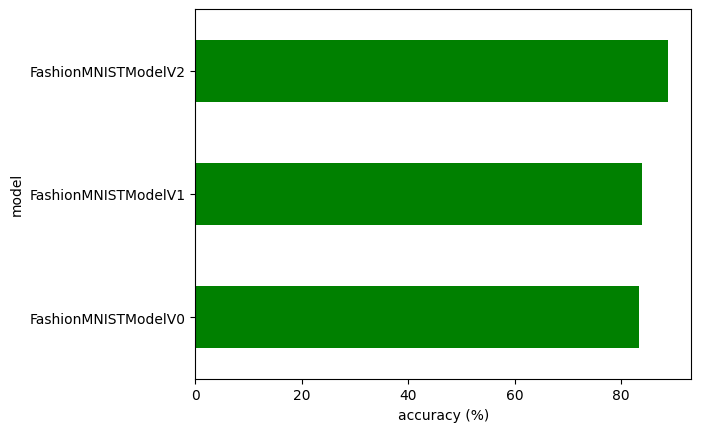

In [345]:
# visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh", color="green")
plt.xlabel("accuracy (%)")
plt.ylabel("model"),

### 9. Make and evalute random predictions with best model.

In [346]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for sample in data:
      # prepare the sample (add a batch dimenssion and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass
      pred_logit = model(sample)

      # Get prediction probability
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      # Get pred_prob off the GPU further calculation
      pred_probs.append(pred_prob.cpu())

  # stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [347]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

  # view the first sample shape
  test_samples[0].shape

Text(0.5, 1.0, 'Sandal')

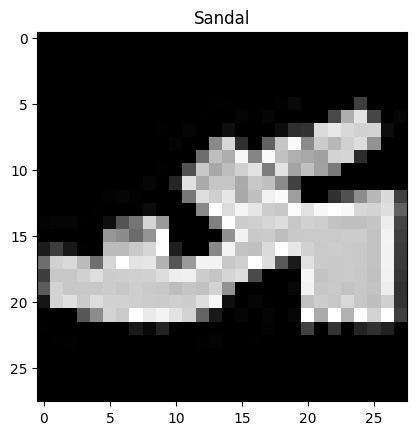

In [348]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [349]:
# make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# view first two prediction probabilities
pred_probs[:2]

tensor([[1.4046e-08, 8.4447e-10, 1.6385e-09, 1.1620e-08, 1.2907e-10, 9.9993e-01,
         7.8738e-07, 9.8818e-07, 2.5965e-06, 6.4746e-05],
        [9.2092e-03, 2.6402e-01, 8.4590e-04, 7.1273e-01, 7.4240e-03, 1.5067e-04,
         4.7198e-03, 4.2773e-04, 3.8473e-04, 8.6682e-05]])

In [350]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

In [351]:
# convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 3, 7, 4, 3, 0, 4, 7, 1])

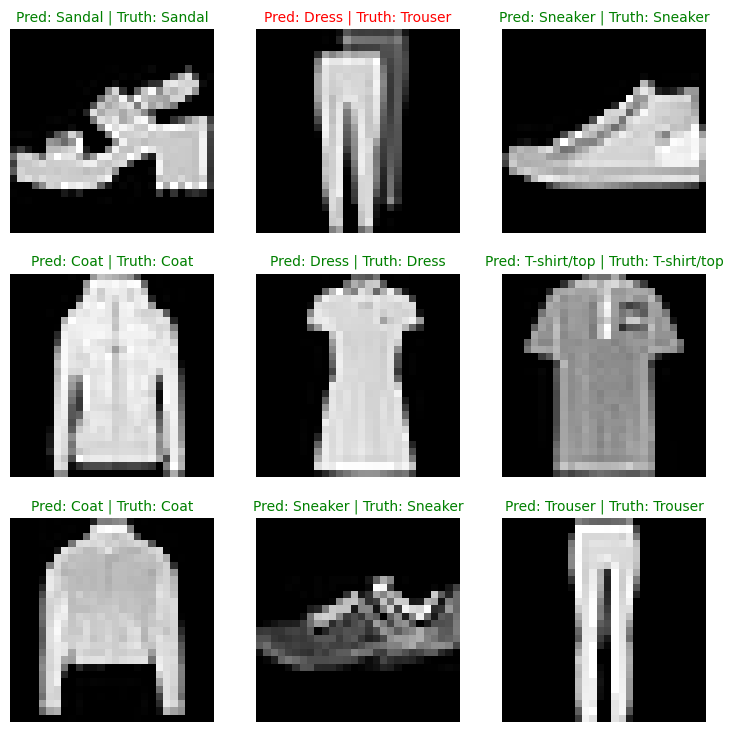

In [352]:
# plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols  = 3
for i, sample in enumerate(test_samples):
  # create subplot
  plt.subplot(nrows, ncols, i+1)

  # plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

   # Find prediction(in text form, e.g "sandal")
  pred_label = class_names[pred_classes[i]]

   # Get the truth lable(in text form)
  truth_label = class_names[test_labels[i]]

  # create a title for the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g") # green text if prediction same as truth

  else:
    plt.title(title_text, fontsize=10, c="r")

  plt.axis("off")

### 10. Making a confusion matrix for further prediction evaluation

1. make prediction matrix based on our model
2. make a confusion matrix
3. plot the confusionmatrix

In [353]:
!pip install --upgrade pip
!pip install mlxtend

In [354]:
import mlxtend

In [355]:
# import tqdm.aouto
from tqdm.auto import tqdm

# 1. make prediction with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for x, y in tqdm(test_dataloader, desc="maling predictions..."):
    # send the data and targets to target device
    x, y = x.to(device), y.to(device)
    # do the forward pass
    y_logit = model_2(x)
    # Turn predictions from logits
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
    # put prediction on CPU for evaluation
    y_preds.append(y_pred.cpu())


# concatenet list of predictions into a tensor
print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

maling predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

[tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 8, 3, 4, 3, 6, 4, 8, 0, 2, 5, 7, 5,
        1, 6, 6, 0, 9, 3, 8, 8]), tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 3, 9, 6, 7, 2, 3, 2, 2, 4, 2, 5, 6, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5]), tensor([1, 1, 3, 3, 7, 8, 7, 0, 2, 6, 4, 3, 1, 2, 8, 4, 3, 8, 5, 9, 5, 0, 3, 2,
        0, 6, 5, 3, 6, 7, 1, 8]), tensor([6, 1, 4, 6, 3, 6, 7, 6, 7, 8, 5, 7, 9, 4, 2, 5, 7, 0, 5, 2, 8, 6, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 4]), tensor([1, 5, 4, 1, 9, 1, 8, 6, 6, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 6, 3, 8,
        1, 3, 5, 6, 4, 7, 9, 3]), tensor([7, 2, 3, 8, 0, 9, 4, 8, 8, 2, 6, 5, 8, 1, 2, 1, 3, 6, 9, 1, 0, 8, 3, 6,
        7, 9, 9, 4, 4, 7, 1, 2]), tensor([3, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        3, 6, 7, 4, 8, 5, 2, 0]), tensor([7, 7, 6, 6, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 3, 2, 5, 4, 9, 2, 2, 8, 6, 4,
        3, 2, 9, 7, 3, 3, 5, 4]), tensor([8, 5, 2, 3, 0, 4, 8, 6, 0, 6, 3, 8, 9, 6, 1, 3, 0, 2, 3, 0, 8, 3, 7, 4,
       

tensor([9, 2, 1,  ..., 0, 1, 0])

In [356]:
len(y_pred_tensor)

10000

In [357]:
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

    # ✅ correct version check
    version = list(map(int, mlxtend.__version__.split(".")))
    assert version[1] >= 20, "mlxtend version must be 0.20.0 or above"

except Exception as e:
    print("Fixing environment...", e)

    !pip uninstall -y numpy
    !pip install numpy==1.26.4
    !pip install -U torchmetrics mlxtend

    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


In [358]:
# see if required pakages are installed and if not , install them...
try:
  import torchmetrics, mlxtend
  print(f"mlxtend: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(" . ")[1] >=19, " mlxtend version be 0.20.0 or above")
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")


mlxtend: 0.24.0
mlxtend version: 0.24.0


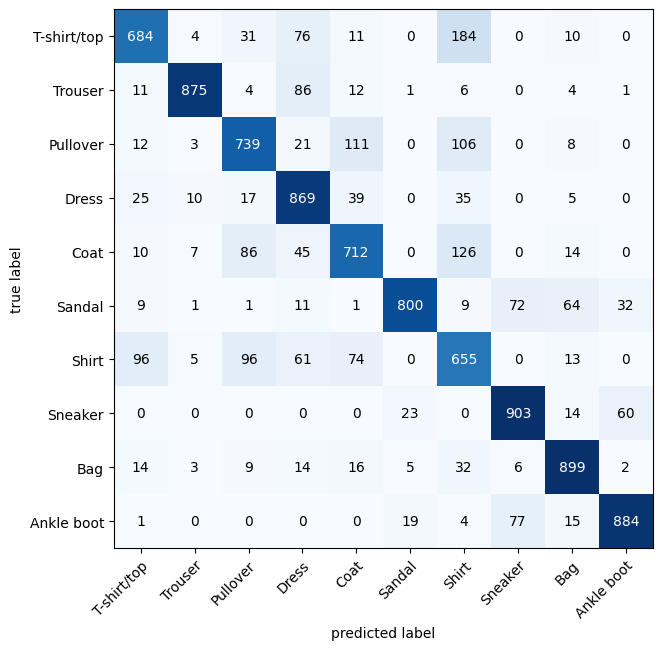

In [359]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. setup confusion instance and compare prediction to targets
confmat = ConfusionMatrix(task="multiclass",
                          num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. plot the confusion matrix
fig, ax= plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize = (10,7)
)

### 11. Save and Loading pytorch model

In [369]:
from pathlib import Path

# create model dictionary
MODEL_PATH= Path("Model")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# create model save
MODEL_NAME = " 04_pytorch_computer_version_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

saving model to: Model/ 04_pytorch_computer_version_model_2.pth


In [367]:
from pathlib import Path

# create model dictionary
MODEL_PATH= Path("Model")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# create model save
MODEL_NAME = "04_pytorch_computer_version_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
             f=MODEL_SAVE_PATH)

saving model to: Model/04_pytorch_computer_version_model_2.pth


In [370]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2378,  0.4069, -0.3519],
                        [ 0.5076,  0.2576,  0.0155],
                        [-0.1878,  0.0209, -0.0189]]],
              
              
                      [[[-0.8947,  0.5260, -0.0353],
                        [ 0.0201,  0.5889,  0.1638],
                        [-0.4092,  0.1594, -0.1046]]],
              
              
                      [[[-0.2452, -0.0836,  0.1886],
                        [-1.1494, -1.0907,  0.2994],
                        [-1.2030, -0.7531,  0.2100]]],
              
              
                      [[[-0.5742, -0.6695, -0.9260],
                        [ 0.2563, -0.6000,  0.0750],
                        [ 0.0345, -0.1357,  0.4818]]],
              
              
                      [[[-0.1715,  0.5430,  0.0855],
                        [-0.3193,  0.4140,  0.0209],
                        [-0.3052,  0.1206,  0.2260]]],
              
              
      

In [372]:
# create new indtance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))


# Load in the save satet dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# send the model to the target device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [373]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3161151717288997,
 'model_acc': 88.7979233226837}

In [375]:
# Evaluation loaded model
torch.manual_seed(42)
loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn= loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3161151717288997,
 'model_acc': 88.7979233226837}

In [377]:
# check if model results are closer to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-02)

tensor(True)